# Import libraries

In [20]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
pd.set_option('display.expand_frame_repr', False)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import joblib

df=pd.read_csv(r"../data/data.csv", encoding='ISO-8859-1')
print(df.head(10))
print(df.shape)

  InvoiceNo StockCode                          Description  Quantity     InvoiceDate  UnitPrice  CustomerID         Country
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6  12/1/2010 8:26       2.55     17850.0  United Kingdom
1    536365     71053                  WHITE METAL LANTERN         6  12/1/2010 8:26       3.39     17850.0  United Kingdom
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8  12/1/2010 8:26       2.75     17850.0  United Kingdom
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6  12/1/2010 8:26       3.39     17850.0  United Kingdom
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6  12/1/2010 8:26       3.39     17850.0  United Kingdom
5    536365     22752         SET 7 BABUSHKA NESTING BOXES         2  12/1/2010 8:26       7.65     17850.0  United Kingdom
6    536365     21730    GLASS STAR FROSTED T-LIGHT HOLDER         6  12/1/2010 8:26       4.25     17850.0  United Kingdom
7    536

# Data cleaning

In [21]:
print(df.shape)
print(df.isnull().sum())
df=df.dropna(subset=["CustomerID"])
print(df.shape)
print(df.isnull().sum())

(541909, 8)
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64
(406829, 8)
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [22]:
print(df.duplicated().sum())
df=df.drop_duplicates()
print(df.shape)

5225
(401604, 8)


In [23]:
print((df['Quantity'] <= 0).sum())
print((df['UnitPrice'] <= 0).sum())
df=df[df['Quantity'] > 0]
df=df[df['UnitPrice'] > 0]
print(df.shape)
print(df.info())

8872
40
(392692, 8)
<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    392692 non-null  object 
 1   StockCode    392692 non-null  object 
 2   Description  392692 non-null  object 
 3   Quantity     392692 non-null  int64  
 4   InvoiceDate  392692 non-null  object 
 5   UnitPrice    392692 non-null  float64
 6   CustomerID   392692 non-null  float64
 7   Country      392692 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.0+ MB
None


In [24]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['CustomerID'] = df['CustomerID'].astype(int)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  int64         
 7   Country      392692 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 27.0+ MB
None


**Feature engineering**

In [25]:
df["TotalPrice"]=df["Quantity"]*df["UnitPrice"]

In [26]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(reference_date)

2011-12-10 12:50:00


In [27]:
rfm=df.groupby("CustomerID").agg(
    monetary=('TotalPrice', 'sum'),
    frequency=('InvoiceNo','count'),
    recency=('InvoiceDate', 'max')
)
# print(rfm.head())
rfm['recency']=(reference_date - rfm['recency']).dt.days
# print(rfm.head())
print(rfm.dtypes)

monetary     float64
frequency      int64
recency        int64
dtype: object


In [28]:

scaler=StandardScaler()
x_scaled=scaler.fit_transform(rfm)

# PCA


In [29]:


pca=PCA(n_components=2)
x_pca=pca.fit_transform(x_scaled)

explained=pca.explained_variance_ratio_
print(explained)

print(x_pca.shape)

df_pca= pd.DataFrame(x_pca, columns=["PC1", "PC2"])
print(df_pca.head())

[0.5093507  0.30228188]
(4338, 2)
        PC1       PC2
0  4.046772  5.378810
1  0.794074 -0.645572
2 -0.121991 -0.214106
3  0.225604 -0.688452
4 -1.216585  1.826561


**elbow method**

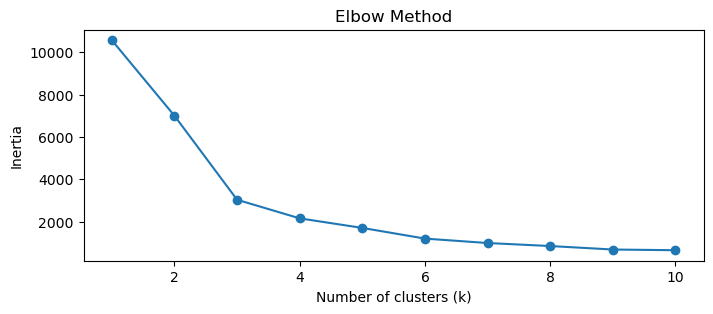

In [30]:

inertia=[]
k_range=range(1,11)

for i in k_range:
    model=KMeans(random_state=42,n_clusters=i)
    model.fit(df_pca)
    inertia.append(model.inertia_)

plt.figure(figsize=(8,3))
plt.plot(k_range,inertia,marker="o")
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show() 
    

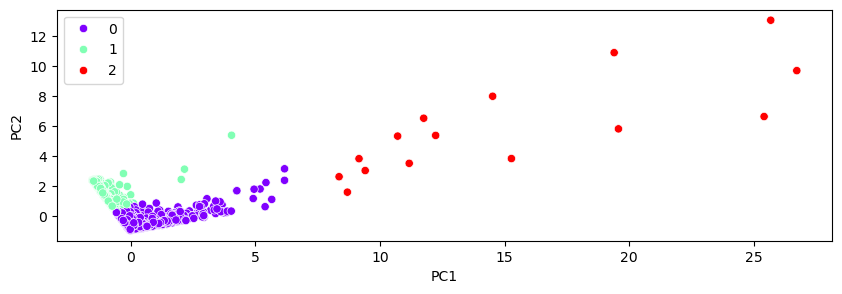

In [31]:
model=KMeans(random_state=42,n_clusters=3,n_init=10)
model.fit(df_pca)
labels=model.labels_

plt.figure(figsize=(10,3))
sns.scatterplot(x=df_pca["PC1"], y=df_pca["PC2"], 
                hue=labels, palette="rainbow")
plt.show()

In [32]:
rfm['Cluster'] = labels
print(rfm.head())
print(rfm.groupby('Cluster').mean())

            monetary  frequency  recency  Cluster
CustomerID                                       
12346       77183.60          1      326        1
12347        4310.00        182        2        0
12348        1797.24         31       75        0
12349        1757.55         73       19        0
12350         334.40         17      310        1
              monetary    frequency     recency
Cluster                                        
0          2003.572241   100.475809   41.465948
1           634.745919    27.242115  247.491651
2        113424.058000  2485.400000    4.666667


In [33]:
print(silhouette_score(df_pca, labels))

0.6280411067300166


In [34]:
joblib.dump(model, '../models/kmeans_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(pca, '../models/pca.pkl')

['../models/pca.pkl']